# 変分量子固有値ソルバー(VQE)による励起状態の計算

VQEは、ハミルトニアンの期待値を最小化するように波動関数を最適化します。そのため、VQEでは基本的に基底状態しか計算できません。今回は、VQEを使って励起状態を計算する方法を説明し、水素分子の励起状態の計算例を示します。

## 理論の概要
今回は、第1励起状態を計算するために[Overlapに基づく手法](https://quantum-journal.org/papers/q-2019-07-01-156/)を使用します。この手法では、VQEから得られる波動関数と基底状態の波動関数との重なり(overlap)に対するペナルティ項を利用します。ハミルトニアンにペナルティ項を加えることで、励起状態を得ることができます。式は以下の通りです。
$$
H^\prime=H+\alpha \mid \psi_{gs}\rangle\langle\psi_{gs} \vert
$$
右辺の $H$ は元のハミルトニアンです。右辺第2項は、基底状態の波動関数 $ \mid \psi_{gs}\rangle$ との重なりの値を評価します(このチュートリアルでは $ \mid \psi_{gs}\rangle$ は古典計算で求めていますが、VQEを使うことも可能です)。第2項の $\alpha$ はペナルティを表すパラメータであり、十分に大きな値を取ります。元の $H$ にペナルティ項を加えることで、左辺の $H^\prime$ を定義します。

VQEから得られる波動関数 $ \mid \psi_{VQE}\rangle$ を使って期待値を評価します。
$$
\langle\psi_{VQE} \mid H^\prime \mid \psi_{VQE}\rangle=\langle\psi_{VQE} \mid H \mid \psi_{VQE}\rangle+\alpha\langle\psi_{VQE} \mid \psi_{gs}\rangle\langle\psi_{gs} \mid \psi_{VQE}\rangle \\
=\langle\psi_{VQE} \mid H \mid \psi_{VQE}\rangle+\alpha \mid \langle\psi_{gs} \mid \psi_{VQE}\rangle \mid ^2
$$
励起状態は基底状態と直交するため、$ \mid \psi_{VQE}\rangle$ が励起状態になれば上式の第2項はゼロになります。今回は、この期待値を使ってVQEにおける水素分子の励起状態計算を実装します。

なお、求めたい波動関数が第1励起状態ではなく第 $N$ 励起状態である場合、基底状態から第 $(N-1)$ 励起状態までの波動関数を使ってペナルティ項を作成します。
$$
H^\prime=H+\sum_{i=gs}^{N-1}\alpha_i \mid \psi_{i}\rangle\langle\psi_{i} \mid 
$$

## 準備
必要なライブラリをインストールします。ハミルトニアンはOpenFermionを使って取得します。

In [1]:
!pip install git+https://github.com/blueqat/blueqatSDK openfermion openfermionpyscf pyscf

/Users/yuichirominato/.pyenv/shims/pip: line 8: /opt/homebrew/opt/pyenv/bin/pyenv: No such file or directory


必要なライブラリをインポートします。VQEの最適化にはSciPyのminimizeを使用します。

In [2]:
from blueqat import Circuit
from openfermion import MolecularData, get_fermion_operator, jordan_wigner, get_sparse_operator
from openfermionpyscf import run_pyscf
import numpy as np
from scipy.optimize import minimize

## Ansatzの定義と分子情報の取得
VQEの計算と分子の情報取得のための関数を定義します。計算にはHardware Efficient Ansatzを使用します。初期波動関数は $\mid1010\rangle$ に設定します。
分子の情報はOpenFermionを使って取得します。基底関数系はSTO-3Gです。

(キャッシュされた分子データが見つからない場合は、PySCFを使ってHartree-FockおよびFCIエネルギーをその場で計算します。)

In [3]:
def HEA(params,n_qubits,n_depth):
    #Wave function initialization |1010>
    circ=Circuit().x[1, 3]

    #Circuit creation
    params_devided=np.array_split(params,n_depth)
    for params_one_depth in params_devided:
        for i,param in enumerate(params_one_depth):
            if i < n_qubits:
                circ.ry(param)[i]
            else:
                circ.rz(param)[i%n_qubits]
        for qbit in range(n_qubits):
            if qbit < n_qubits-1:
                circ.cz[qbit,qbit+1]
    
    #Running the circuit (statevector as a NumPy array)
    wf = circ.run().numpy()
    return wf

def get_molecule(length):
    geometry = [('H',(0.,0.,0.)),('H',(0.,0.,length))]
    description = f'{length:.2f}'
    molecule = MolecularData(geometry, "sto-3g",1,description=description)
    try:
        molecule.load()
    except (FileNotFoundError, OSError, KeyError):
        # No cached data found: compute Hartree-Fock/FCI with PySCF instead.
        molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
        molecule.save()
    return molecule

## 期待値とコスト関数
VQEから得られた波動関数を使って期待値を計算します。期待値の計算では、元のハミルトニアンの期待値に、基底状態とVQEの波動関数との重なりに関する項が追加されます。

In [4]:
def expect_excited_state(wf,hamiltonian,penalty,wf_gs):
    #Calculating Hamiltonian+penalty 
    hamiltonian_overlap = np.vdot(wf, hamiltonian.dot(wf)).real+penalty*np.abs(np.vdot(wf_gs,wf))**2
    return hamiltonian_overlap

def cost(params,hamiltonian,n_qubits,n_depth,penalty,wf_gs):
    wf=HEA(params,n_qubits,n_depth)
    return expect_excited_state(wf,hamiltonian,penalty,wf_gs)

## 計算の実行とプロット
各結合長についてVQEを実行します(数分かかります)。今回、基底状態の波動関数は古典的に求めていますが、VQEで計算することも可能です。ペナルティの値は10ハートリーです。
計算後、VQE、基底状態、第1励起状態の計算結果をエネルギーと結合長について比較します。

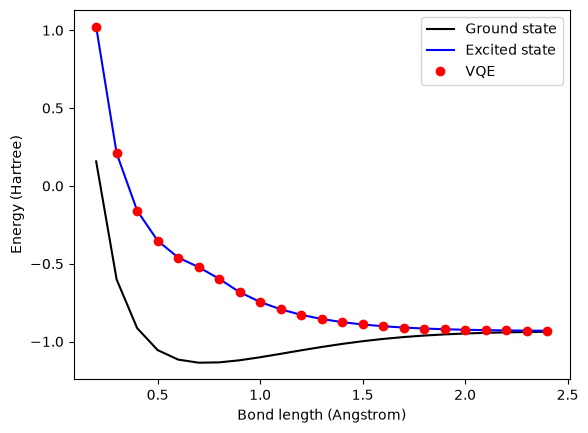

In [5]:
#For recording bond length, VQE, ground state and 1st excited state results
bond_len_list = [];VQE_energy_list=[];gs_list=[];es_list=[]
#Execute the calculation for each bond length
for bond_len in np.arange(0.2,2.5,0.1):
    molecule = get_molecule(bond_len)
    #Determination of the number of bits, depth, initial parameter, and penalty
    n_qubits=molecule.n_qubits
    n_depth=4
    init_params=np.random.rand(2*n_qubits*n_depth)*0.1
    penalty=10
    #Hamiltonian Definition
    hamiltonian_gs = get_sparse_operator(jordan_wigner(get_fermion_operator(molecule.get_molecular_hamiltonian())))

    #Obtaining the eigenvalues and eigenvectors using classical calculation
    eigen_energy, eigen_vec =np.linalg.eigh((hamiltonian_gs).toarray())
    #Obtaining the wave function of the ground state
    wf_gs=eigen_vec.T[np.argmin(eigen_energy)]

    #Optimization run
    result=minimize(cost,x0=init_params,args=(hamiltonian_gs,n_qubits,n_depth,penalty,wf_gs))

    #Recording bond length, VQE, ground state and 1st excited state results
    bond_len_list.append(bond_len)
    VQE_energy_list.append(result.fun)
    gs_list.append(sorted(eigen_energy)[0])
    es_list.append(sorted(eigen_energy)[1])

#Plotting
import matplotlib.pyplot as plt
plt.plot(bond_len_list,gs_list,label="Ground state",color="black")
plt.plot(bond_len_list,es_list,label="Excited state",color="blue")
plt.plot(bond_len_list,VQE_energy_list, marker="o",label="VQE",color="red",linestyle='None')
plt.xlabel("Bond length (Angstrom)")
plt.ylabel("Energy (Hartree)")
plt.legend()

結果は励起状態の厳密な値とよく一致しています。ここではOverlapに基づく手法を使いましたが、励起状態を計算する手法は他にも様々なものがあります。したがって、[このレビュー論文](https://arxiv.org/abs/1808.10402)などを参考に、目的に合った手法を試してみてください。